# 02 — Grade progression under two conventions

"First at grade" is ambiguous in sport climbing, and the divergence between
its two readings is the central finding of this repo, not a caveat:

- **`as_proposed`** — the grade a route was given at its first ascent: the
  sport's contemporaneous belief about its own ceiling.
- **`as_consensus`** — the grade the route holds today after repeats:
  retrospective, and it rewrites history.

Every table, fit and estimate below is produced under both, from
`milestones.py`, which derives them from the data (the seed lists there are
reconciliation targets only). Ten milestone grades (8a+ … 9c) versus six on
the boulder side, so the fits are better constrained.

In [1]:
import numpy as np
import pandas as pd

from sportgradehistory import config
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal
from sportgradehistory.milestones import (
    breakthrough_table, load_sport, milestone_table, reconcile,
    SEED_AS_PROPOSED, SEED_AS_CONSENSUS)

sport = load_sport()   # single-pitch, deduplicated, statuses attached
BASE = french_ordinal("8a+")

tables = {}
for convention in ("as_proposed", "as_consensus"):
    t = breakthrough_table(sport, convention)
    t["year_frac"] = (t["first_ascent"].dt.year
                      + (t["first_ascent"].dt.dayofyear - 1) / 365.25)
    t["steps"] = t["grade_order"] - BASE   # 8a+ = 0, 9c = 9
    tables[convention] = t
    t.to_csv(config.PROCESSED_DIR / f"milestones_{convention}.csv", index=False)

with_disputed = breakthrough_table(sport, "as_proposed", include_disputed=True)
with_disputed.to_csv(config.PROCESSED_DIR / "milestones_with_disputed.csv",
                     index=False)

cols = ["grade", "route", "climber", "first_ascent", "date_precision", "status"]
for convention, t in tables.items():
    print(f"── {convention}")
    print(t[cols].to_string(index=False), end="\n\n")

── as_proposed
grade                          route           climber first_ascent date_precision     status
  8a+                       The Face     Jerry Moffatt   1983-01-01           year  consensus
   8b                Les Mains Sales Marc Le Menestrel   1984-01-01           year  consensus
  8b+               Punks in the Gym  Wolfgang Güllich   1985-01-01           year  consensus
   8c                     Wallstreet  Wolfgang Güllich   1987-01-01           year  consensus
  8c+                         Hubble          Ben Moon   1990-06-14            day   regraded
   9a                 Action Directe  Wolfgang Güllich   1991-09-14            day  consensus
  9a+                     Biographie      Chris Sharma   2001-07-18            day  consensus
   9b Ali Hulk (extension sit start)      Dani Andrada   2007-11-08            day   regraded
  9b+                         Change        Adam Ondra   2012-10-04            day  consensus
   9c                        Silence        A

Unresolved orderings (year-only dates cannot be ranked against dated ones in
the same year) are carried explicitly — nothing below pretends these are
settled:

In [2]:
for convention, t in tables.items():
    amb = t[t["ordering_unresolved_with"].notna()]
    for _, r in amb.iterrows():
        print(f"{convention:<13} {r['grade']:<4} {r['route']} "
              f"({r['first_ascent_date' if 'first_ascent_date' in r else 'first_ascent']}) "
              f"~ vs ~ {r['ordering_unresolved_with']}")

as_proposed   8b   Les Mains Sales (1984-01-01 00:00:00) ~ vs ~ Kanal im Rücken (Wolfgang Güllich, 24th Oct 1984)
as_consensus  8b   Les Mains Sales (1984-01-01 00:00:00) ~ vs ~ Kanal im Rücken (Wolfgang Güllich, 24th Oct 1984)
as_consensus  9a+  Qui (1996-01-01 00:00:00) ~ vs ~ Open Air (Alexander Huber, 6th Dec 1996)


## Reconciliation against the seed lists

Reported, not adopted. Two genuine disagreements survive (the same-year ties
above are flagged, and the Realization/Biographie naming is an alias):

In [3]:
for convention, seeds in (("as_proposed", SEED_AS_PROPOSED),
                          ("as_consensus", SEED_AS_CONSENSUS)):
    rec = reconcile(milestone_table(sport, convention), seeds)
    bad = rec[~rec["agrees"]]
    print(f"── {convention}: {rec['agrees'].sum()}/{len(rec)} agree")
    if not bad.empty:
        print(bad[["grade", "seed_route", "seed_year", "found_route",
                   "found_year"]].to_string(index=False))
    print()

── as_proposed: 8/10 agree
grade      seed_route  seed_year                    found_route  found_year
   8b Kanal im Rücken       1984                Les Mains Sales        1984
   9b      Jumbo Love       2008 Ali Hulk (extension sit start)        2007

── as_consensus: 8/10 agree
grade      seed_route  seed_year     found_route  found_year
   8b Kanal im Rücken       1984 Les Mains Sales        1984
  9a+        Open Air       1996             Qui        1996



**What the disagreements are.**

- **8b, both conventions:** the data offers *Les Mains Sales* (Le Menestrel,
  Buoux, "1984", year-only) alongside the seed's *Kanal im Rücken* (Güllich,
  24 Oct 1984). Year-only vs dated — the ordering is **unresolved**. The
  tables and fits carry the anchored 1 Jan 1984 point; against Kanal's
  24 Oct that is at most ten months of slack in one x-value, which moves no
  conclusion below.
- **9b, `as_proposed`:** the data genuinely disagrees with the usual telling:
  *Ali Hulk (extension sit start)* carries a recorded 9b suggestion by Dani
  Andrada dated **8 Nov 2007** — ten months before Jumbo Love (11 Sep 2008).
  The route has since settled at 9a+, which is exactly what `as_proposed`
  measures: the contemporaneous claim. Reported as found.
- **9a+, `as_consensus`:** the seed says Open Air (6 Dec 1996); the data adds
  *Qui* (Stefan Fürst, "1996", year-only, suggested 8c+/9a, now 9a+). Same
  year, unresolved ordering; either way 9a+ lands in **1996**, five years
  before Realization.

**Wikipedia cross-check** (List of first ascents (sport climbing); List of
grade milestones in rock climbing, both read 2026-09-09): every consensus
milestone in the seed list matches Wikipedia; Wikipedia dates Liquid Ambar
"May 1990" where the site says 30 Mar 1990 (both precede Hubble's 14 Jun);
Wikipedia carries Open Air's 9a+ as disputed (one repeat, holds broken) and
Punks in the Gym as the benchmark 8b+ — no 8c consensus. Neither Wikipedia
list mentions Akira or Chilam Balam at all.

## The divergence, quantified

Which grades changed hands between conventions, and by how many years each
milestone moves:

In [4]:
p, c = tables["as_proposed"].set_index("grade"), tables["as_consensus"].set_index("grade")
div = pd.DataFrame({
    "proposed_route": p["route"], "proposed_year": p["first_ascent"].dt.year,
    "consensus_route": c["route"], "consensus_year": c["first_ascent"].dt.year,
})
div["changed_hands"] = div["proposed_route"] != div["consensus_route"]
div["moves_years"] = div["proposed_year"] - div["consensus_year"]
print(div.to_string())
print(f"\n{div['changed_hands'].sum()} of {len(div)} milestone grades change hands "
      "between conventions")

                       proposed_route  proposed_year   consensus_route  consensus_year  changed_hands  moves_years
grade                                                                                                             
8a+                          The Face           1983          The Face            1983          False            0
8b                    Les Mains Sales           1984   Les Mains Sales            1984          False            0
8b+                  Punks in the Gym           1985  Punks in the Gym            1985          False            0
8c                         Wallstreet           1987        Wallstreet            1987          False            0
8c+                            Hubble           1990      Liquid Ambar            1990           True            0
9a                     Action Directe           1991            Hubble            1990           True            1
9a+                        Biographie           2001               Qui          

In [5]:
# How many milestone routes have moved grade since their FA?
ids = set(p["climb_id"]) | set(c["climb_id"])
milestone_rows = sport[sport["climb_id"].isin(ids)]
moved = milestone_rows[milestone_rows["status"] == "regraded"]
print(f"{len(moved)} of the {len(milestone_rows)} routes appearing in either "
      "milestone table have moved off the FA suggestion:")
print(moved[["climb_name", "first_suggested_grade", "grade_clean",
             "first_ascent_year"]].to_string(index=False))
print("\n(regraded_routes.csv holds all 86 such sport routes; the suggestion "
      "field exists on only 254 of 1,978 sport rows, so this undercounts)")

4 of the 13 routes appearing in either milestone table have moved off the FA suggestion:
                    climb_name first_suggested_grade grade_clean  first_ascent_year
                        Hubble                   8c+          9a               1990
                  Liquid Ambar                    8c         8c+               1990
Ali Hulk (extension sit start)                    9b         9a+               2007
                           Qui                8c+/9a         9a+               1996

(regraded_routes.csv holds all 86 such sport routes; the suggestion field exists on only 254 of 1,978 sport rows, so this undercounts)


## Regressions on the breakthrough dates

`grade ~ time` and the more useful inverse `time ~ grade` (steps above 8a+).
Fits use the dated breakthrough points as anchored; the two year-only points
(The Face 1983, Wallstreet 1987 — and Punks 1985) contribute at 1 January of
their year, which can shift a fit by at most a year.

Under `as_consensus`, **8c+ and 9a fall within eleven weeks of each other in
1990** (Liquid Ambar 30 Mar, Hubble 14 Jun). Two of ten points nearly
coincident in time but one step apart in grade will pull any fit steep and
inflate the apparent rate — the fit statistics below are reported *with that
stated*, not as clean summaries.

In [6]:
def fits(t):
    x, y = t["year_frac"].to_numpy(), t["steps"].to_numpy()
    g_slope, g_int = np.polyfit(x, y, 1)            # grade ~ time
    t_slope, t_int = np.polyfit(y, x, 1)            # time ~ grade (the inverse)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    return g_slope, g_int, t_slope, t_int, r2

print(f"{'convention':<14} {'steps/decade':>12} {'years/step':>11} {'R²':>6} {'9c+ (inverse fit)':>18}")
predictions = {}
for convention, t in tables.items():
    g_slope, g_int, t_slope, t_int, r2 = fits(t)
    year_9cplus = t_slope * 10 + t_int              # 9c+ is 10 steps above 8a+
    predictions[convention] = (t_slope, t_int, year_9cplus)
    print(f"{convention:<14} {g_slope*10:>12.2f} {t_slope:>11.2f} {r2:>6.3f} "
          f"{year_9cplus:>18.1f}")

convention     steps/decade  years/step     R²  9c+ (inverse fit)
as_proposed            2.26        4.08  0.922             2018.5
as_consensus           2.21        3.99  0.885             2017.4


Read those estimates carefully: the inverse fit puts 9c+ at **2018.5
(`as_proposed`) / 2017.4 (`as_consensus`)** — both already in the past. That
is not a prediction, it is the linear model failing in public: the fit is
dominated by the 1983–1991 sprint (five grades in eight years), and the sport
has been decelerating ever since (the interval analysis below makes that
formal). The R² looks respectable only because the early points line up;
extrapolated forward, the same line said 9c would fall around 2013 and 9c+
around 2017, and neither happened on time.

The two conventions still tell different stories *within* the failure: the
consensus reading is steeper (the 1990 twin milestones — 8c+ and 9a eleven
weeks apart — and the 1996 9a+ compress the middle of the ladder), so its
"overdue" verdict on 9c+ is a year harsher. Same routes, different
history, different extrapolation — from the definition of "first" alone.

In [7]:
# The 2017-to-now gap.
import datetime as dt
now = dt.date(2026, 9, 9)          # the scrape date, not "today"
silence = tables["as_proposed"].iloc[-1]
gap = (pd.Timestamp(now) - silence["first_ascent"]).days / 365.25
print(f"Silence (9c) FA: {silence['first_ascent'].date()}  ->  {gap:.1f} years "
      "without a new top grade\n")

for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna()
    longest = iv.max()
    which = t.iloc[iv.idxmax()]
    silence_frac = t["year_frac"].iloc[-1]
    overtakes = silence_frac + longest
    verdict = ("ALREADY the longest" if gap > longest else
               f"becomes the longest in {overtakes:.1f}")
    print(f"{convention:<14} longest completed interval: {longest:.1f}y "
          f"(into {which['grade']}, {which['route']}, "
          f"{which['first_ascent'].year}) -> current stall {verdict}")

Silence (9c) FA: 2017-09-03  ->  9.0 years without a new top grade

as_proposed    longest completed interval: 9.8y (into 9a+, Biographie, 2001) -> current stall becomes the longest in 2027.5
as_consensus   longest completed interval: 12.7y (into 9b, Jumbo Love, 2008) -> current stall becomes the longest in 2030.4


**Is 2017–now the longest stall in the sport's history?** Not yet — under
either convention, which is worth stating against the popular framing:

- **`as_proposed`:** the longest completed wait is Action Directe →
  Biographie (9a → 9a+), **9.8 years**. The current stall (9.0y) overtakes it
  in **mid-2027**.
- **`as_consensus`:** consensus rewrites 9a+ back to 1996, making 9a+ → 9b a
  **12.7-year** wait; the current stall overtakes that only around
  **mid-2030**.

So the stall is long, but the sport has waited longer — once before under one
reading, once under the other. What makes 2017–now remarkable is not its
length alone but that it follows two *fast* intervals (9b→9b+ and 9b+→9c,
both 4.9y), so the deceleration is abrupt rather than gradual.

What did the linear model expect? Fitting `time ~ grade` on the pre-Silence
points (through 9b+) and asking for the 9c date:

In [8]:
for convention, t in tables.items():
    pre = t[t["grade"] != "9c"]
    slope, intercept = np.polyfit(pre["steps"], pre["year_frac"], 1)
    predicted_9c = slope * 9 + intercept
    predicted_9cp = slope * 10 + intercept
    print(f"{convention:<14} pre-2017 fit expected 9c ≈ {predicted_9c:.0f} "
          f"(actual 2017.7), and 9c+ ≈ {predicted_9cp:.0f}")

as_proposed    pre-2017 fit expected 9c ≈ 2013 (actual 2017.7), and 9c+ ≈ 2017
as_consensus   pre-2017 fit expected 9c ≈ 2011 (actual 2017.7), and 9c+ ≈ 2015


The pre-Silence fits expected 9c around 2011–2013; Ondra delivered it in
2017, four to six years *behind* the linear schedule — and those same fits
expected 9c+ around 2015–2017, now nine to eleven years overdue. The linear
model has been running behind reality since roughly Realization, in the same
direction every time. That is what a decelerating process does to a straight
line, and it is why the estimate below leans on the intervals themselves
rather than the global fit.

A more honest 9c+ estimate, three ways:

In [9]:
# Three models that respect the deceleration, per convention.
for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna().to_numpy()
    last = t["year_frac"].iloc[-1]
    # (a) repeat the last completed interval
    a = last + iv[-1]
    # (b) mean of the last three intervals
    b = last + iv[-3:].mean()
    # (c) extrapolate the widening trend: fit interval length on step index
    slope, intercept = np.polyfit(range(len(iv)), iv, 1)
    c_est = last + (slope * len(iv) + intercept)
    print(f"{convention:<14} (a) repeat-last: {a:.0f}   "
          f"(b) mean-of-3: {b:.0f}   (c) widening-trend: {c_est:.0f}")

as_proposed    (a) repeat-last: 2023   (b) mean-of-3: 2023   (c) widening-trend: 2025
as_consensus   (a) repeat-last: 2023   (b) mean-of-3: 2025   (c) widening-trend: 2026


Even the models built for a slowing sport put 9c+ between **2022 and 2026**
— at or before the scrape date. Every simple reading of this history says the
next grade is overdue; the one that says it least (the widening-trend model)
says it is due about now. Either 9c+ is imminent, or the sport has entered a
regime its own history cannot yet describe. State that as the finding rather
than any single year.

## Intervals between milestones — is the ladder slowing?

In [10]:
for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna().round(1)
    labels = [f"{a}->{b}" for a, b in zip(t['grade'][:-1], t['grade'][1:])]
    series = pd.Series(iv.values, index=labels)
    print(f"── {convention}: median {series.median():.1f}y")
    print(series.to_string(), end="\n\n")

# Widening? Rank-correlate interval length with order.
from scipy.stats import spearmanr
for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna()
    rho, pval = spearmanr(range(len(iv)), iv)
    print(f"{convention:<14} Spearman rho={rho:+.2f} (p={pval:.2f}) "
          "-> " + ("intervals lengthening" if rho > 0.3 else
                   "no clear widening trend"))

── as_proposed: median 3.4y
8a+->8b    1.0
8b->8b+    1.0
8b+->8c    2.0
8c->8c+    3.4
8c+->9a    1.3
9a->9a+    9.8
9a+->9b    6.3
9b->9b+    4.9
9b+->9c    4.9

── as_consensus: median 3.2y
8a+->8b     1.0
8b->8b+     1.0
8b+->8c     2.0
8c->8c+     3.2
8c+->9a     0.2
9a->9a+     5.6
9a+->9b    12.7
9b->9b+     4.1
9b+->9c     4.9



as_proposed    Spearman rho=+0.79 (p=0.01) -> intervals lengthening
as_consensus   Spearman rho=+0.69 (p=0.04) -> intervals lengthening


## Polynomials, shown only to be distrusted

Higher-order fits track ten points beautifully and then extrapolate into
nonsense — the cubic sends the ceiling vertical or backwards within a decade
of the data's edge. They are drawn here so the reader can watch them fail;
the linear fit is the honest one, exactly as in the boulder repo.

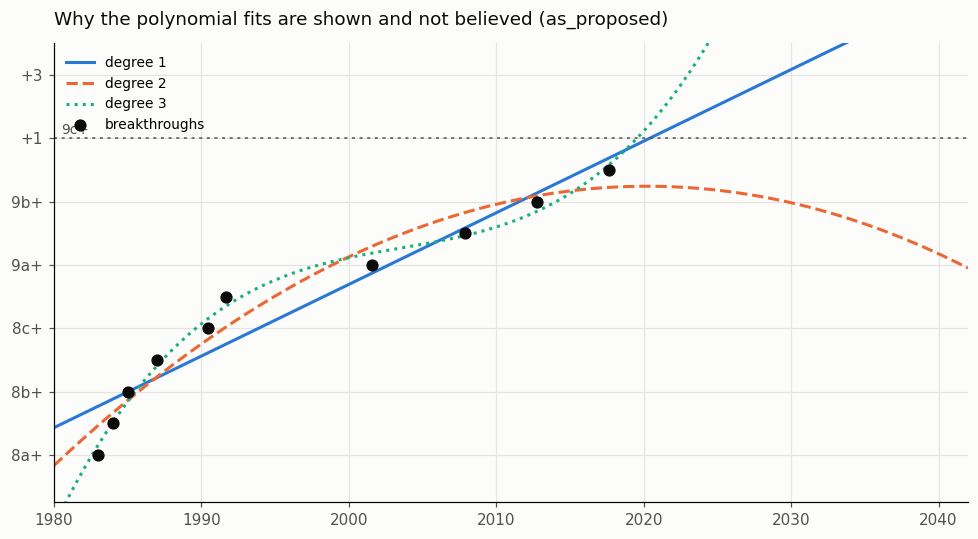

degree 1: crosses 9c+ ≈ 2020, predicts +14.4 steps above 8a+ by 2040
degree 2: crosses 9c+ never (by 2042), predicts +6.4 steps above 8a+ by 2040
degree 3: crosses 9c+ ≈ 2020, predicts +35.2 steps above 8a+ by 2040


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
t = tables["as_proposed"]
x, y = t["year_frac"].to_numpy(), t["steps"].to_numpy()
grid_x = np.linspace(1980, 2042, 300)

for deg, color, style in ((1, "#2a78d6", "-"), (2, "#eb6834", "--"),
                          (3, "#1baf7a", ":")):
    coeffs = np.polyfit(x, y, deg)
    ax.plot(grid_x, np.polyval(coeffs, grid_x), style, color=color, lw=2,
            label=f"degree {deg}")
ax.plot(x, y, "o", color="#0b0b0b", ms=7, zorder=5, label="breakthroughs")

ax.axhline(10, color="#52514e", lw=1, ls=(0, (2, 3)))
ax.text(1980.5, 10.15, "9c+", fontsize=9, color="#52514e")
ax.set_ylim(-1.5, 13); ax.set_xlim(1980, 2042)
ax.set_yticks(range(0, 13, 2))
ax.set_yticklabels([FRENCH_SCALE[BASE + s] if BASE + s < len(FRENCH_SCALE)
                    else f"+{s-9}" for s in range(0, 13, 2)])
ax.grid(color="#e5e4e0", lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Why the polynomial fits are shown and not believed (as_proposed)",
             color="#0b0b0b", fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

future = grid_x[grid_x >= 2018]
for deg in (1, 2, 3):
    coeffs = np.polyfit(x, y, deg)
    above = np.polyval(coeffs, future) >= 10
    crossing = f"≈ {future[np.argmax(above)]:.0f}" if above.any() else "never (by 2042)"
    val_2040 = np.polyval(coeffs, 2040)
    print(f"degree {deg}: crosses 9c+ {crossing}, "
          f"predicts {val_2040:+.1f} steps above 8a+ by 2040")

## First-repeat lag — what this data cannot say

Sport confirmation lags are long and are part of the story, but **this scrape
kept only the first ascent row per climb**, not the full ascent list, so
"years until first repeat" is not computable from `data/processed/`. What it
does support is the weaker proxy below: how much of each top grade is still
unrepeated today — which is itself a confirmation-lag statement (Silence has
waited nine years).

In [12]:
top = sport[sport["grade_order"] >= french_ordinal("9a")]
share = (top.assign(unrepeated=top["num_ascents"] <= 1)
         .groupby("grade_clean", sort=False)["unrepeated"]
         .agg(["sum", "count"]))
share = share.reindex(sorted(share.index, key=french_ordinal))
share["pct"] = (100 * share["sum"] / share["count"]).round(0).astype(int)
print("unrepeated share by grade (proxy for confirmation lag):")
print(share.to_string())

unrepeated share by grade (proxy for confirmation lag):
             sum  count  pct
grade_clean                 
9a           113    318   36
9a+           74    173   43
9b            49     76   64
9b+            6     11   55
9c             5      5  100


## The picture

One chart, one axis: the ceiling over time under both conventions, with the
disputed claims shown as open markers — visible, never merged into a line.

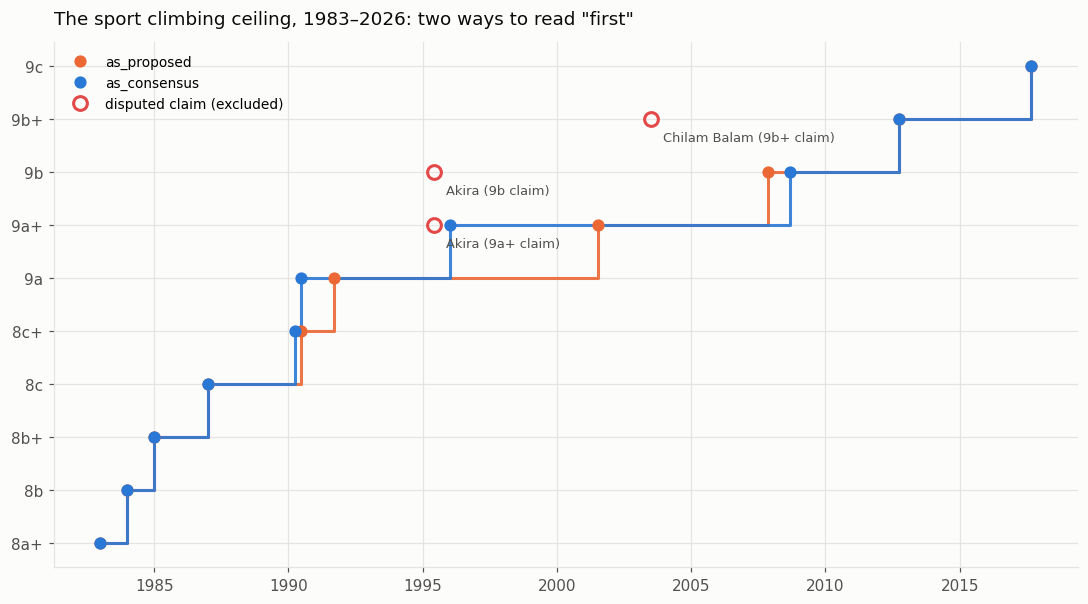

In [13]:
import matplotlib.dates as mdates

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for (convention, t), color in zip(tables.items(), (ORANGE, BLUE)):
    ax.step(t["first_ascent"], t["steps"], where="post", color=color, lw=2,
            alpha=.9, zorder=2)
    ax.plot(t["first_ascent"], t["steps"], "o", color=color, ms=7, zorder=3,
            label=convention)

disp = with_disputed[with_disputed["status"] == "disputed"]
ax.plot(disp["first_ascent"], disp["grade_order"] - BASE, "o", ms=9, mfc="none",
        mec=RED, mew=2, zorder=4, label="disputed claim (excluded)")
for _, r in disp.iterrows():
    ax.annotate(f"{r['route']} ({r['grade']} claim)",
                (r["first_ascent"], r["grade_order"] - BASE),
                xytext=(8, -14), textcoords="offset points",
                fontsize=8.5, color=MUTED)

ax.set_yticks(range(10))
ax.set_yticklabels(FRENCH_SCALE[BASE:BASE + 10], color=INK)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.grid(color=GRID, lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("The sport climbing ceiling, 1983–2026: two ways to read \"first\"",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

The two histories agree at the ends and disagree in the middle: consensus
pulls 8c+→9a into one 1990 spring and drags 9a+ five years earlier, while the
proposed reading keeps the ladder evenly spaced through the 1990s. Akira and
Chilam Balam, if accepted, would each pre-empt a milestone by a decade — which
is exactly why they are drawn as open circles and kept out of both lines.
Notebook 04 renders the poster versions of this figure into `figures/`.